<span style="color: lightblue">

# ML - PROJEKT ZALICZENIOWY
### 1. Project overview

<span>

In [494]:
import kagglehub
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [464]:
path = kagglehub.dataset_download("kukuroo3/body-signal-of-smoking")
df = pd.read_csv(os.path.join(path, "smoking.csv"))
print("Path to dataset files:", path) 


Path to dataset files: /Users/magdalena/.cache/kagglehub/datasets/kukuroo3/body-signal-of-smoking/versions/2


In [465]:
df.head(100)

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,...,12.9,1.0,0.7,18.0,19.0,27.0,Y,0,Y,0
1,1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,...,12.7,1.0,0.6,22.0,19.0,18.0,Y,0,Y,0
2,2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,...,15.8,1.0,1.0,21.0,16.0,22.0,Y,0,N,1
3,3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,...,14.7,1.0,1.0,19.0,26.0,18.0,Y,0,Y,0
4,4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,...,12.5,1.0,0.6,16.0,14.0,22.0,Y,0,N,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,118,M,25,175,65,75.0,1.5,1.5,1.0,1.0,...,14.9,1.0,0.7,15.0,13.0,15.0,Y,0,Y,1
96,119,M,40,170,75,89.0,0.8,1.5,1.0,1.0,...,15.8,1.0,0.9,30.0,23.0,35.0,Y,0,N,1
97,120,M,30,175,75,85.1,1.5,1.5,1.0,1.0,...,14.9,1.0,1.1,14.0,16.0,16.0,Y,0,Y,1
98,121,M,35,160,60,80.3,1.0,1.2,1.0,1.0,...,15.9,1.0,0.9,21.0,27.0,39.0,Y,0,N,0


In [466]:
df.shape
print(f"Dataset zawiera {df.shape[0]} obserwacji i {df.shape[1]} kolumn.")

Dataset zawiera 55692 obserwacji i 27 kolumn.


In [467]:
participant_data = {
    "ID": "Unikalny identyfikator badanego",
    "gender": "Płeć badanego (określone wartości)",
    "age": "Wiek badanego w latach",
    "height(cm)": "Wzrost badanego w centymetrach",
    "weight(kg)": "Waga badanego w kilogramach",
    "waist(cm)": "Obwód talii badanego w centymetrach",
    "eyesight(left)": "Ostrość wzroku w lewym oku",
    "eyesight(right)": "Ostrość wzroku w prawym oku",
    "hearing(left)": "Poziom słuchu w lewym uchu (określone wartości)",
    "hearing(right)": "Poziom słuchu w prawym uchu (określone wartości)",
    "systolic": "Ciśnienie skurczowe krwi badanego",
    "relaxation": "Ciśnienie rozkurczowe krwi badanego",
    "fasting blood sugar": "Poziom glukozy na czczo we krwi badanego",
    "Cholesterol": "Całkowity poziom cholesterolu we krwi",
    "triglyceride": "Poziom trójglicerydów we krwi",
    "HDL": "Poziom cholesterolu HDL we krwi (tzw. dobry cholesterol)",
    "LDL": "Poziom cholesterolu LDL we krwi (tzw. zły cholesterol)",
    "hemoglobin": "Poziom hemoglobiny we krwi badanego",
    "Urine protein": "Zawartość białka w moczu badanego",
    "serum creatinine": "Poziom kreatyniny w surowicy krwi (wskaźnik funkcji nerek)",
    "AST": "Poziom enzymu AST (wskaźnik funkcji wątroby)",
    "ALT": "Poziom enzymu ALT (wskaźnik funkcji wątroby)",
    "Gtp": "Poziom gamma-GTP (wskaźnik funkcji wątroby)",
    "oral": "Stan zdrowia jamy ustnej badanego (ogólna ocena)",
    "dental caries": "Informacja o występowaniu próchnicy",
    "tartar": "Informacja o obecności kamienia nazębnego",
    "smoking": "Informacja o statusie palenia badanego (określone wartości)"
}

print("Semantyczne znaczenie danych ze zbioru:\n")
print("| Dana | Znaczenie |")
print("| :---- | :-------- |")

for key, value in participant_data.items():
    print(f"| {key} | {value} |")


Semantyczne znaczenie danych ze zbioru:

| Dana | Znaczenie |
| :---- | :-------- |
| ID | Unikalny identyfikator badanego |
| gender | Płeć badanego (określone wartości) |
| age | Wiek badanego w latach |
| height(cm) | Wzrost badanego w centymetrach |
| weight(kg) | Waga badanego w kilogramach |
| waist(cm) | Obwód talii badanego w centymetrach |
| eyesight(left) | Ostrość wzroku w lewym oku |
| eyesight(right) | Ostrość wzroku w prawym oku |
| hearing(left) | Poziom słuchu w lewym uchu (określone wartości) |
| hearing(right) | Poziom słuchu w prawym uchu (określone wartości) |
| systolic | Ciśnienie skurczowe krwi badanego |
| relaxation | Ciśnienie rozkurczowe krwi badanego |
| fasting blood sugar | Poziom glukozy na czczo we krwi badanego |
| Cholesterol | Całkowity poziom cholesterolu we krwi |
| triglyceride | Poziom trójglicerydów we krwi |
| HDL | Poziom cholesterolu HDL we krwi (tzw. dobry cholesterol) |
| LDL | Poziom cholesterolu LDL we krwi (tzw. zły cholesterol) |
| hemog

<span style="color: lightblue">

### 2. EDA - Explanatarory data analysis
<span>

In [468]:
print("Lista kolumn w zbiorze danych:")
df.columns

Lista kolumn w zbiorze danych:


Index(['ID', 'gender', 'age', 'height(cm)', 'weight(kg)', 'waist(cm)',
       'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)',
       'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol',
       'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein',
       'serum creatinine', 'AST', 'ALT', 'Gtp', 'oral', 'dental caries',
       'tartar', 'smoking'],
      dtype='object')

In [469]:
print("Braki danych per kolumna:")
df.isna().sum()

Braki danych per kolumna:


ID                     0
gender                 0
age                    0
height(cm)             0
weight(kg)             0
waist(cm)              0
eyesight(left)         0
eyesight(right)        0
hearing(left)          0
hearing(right)         0
systolic               0
relaxation             0
fasting blood sugar    0
Cholesterol            0
triglyceride           0
HDL                    0
LDL                    0
hemoglobin             0
Urine protein          0
serum creatinine       0
AST                    0
ALT                    0
Gtp                    0
oral                   0
dental caries          0
tartar                 0
smoking                0
dtype: int64

In [470]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55692 entries, 0 to 55691
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   55692 non-null  int64  
 1   gender               55692 non-null  object 
 2   age                  55692 non-null  int64  
 3   height(cm)           55692 non-null  int64  
 4   weight(kg)           55692 non-null  int64  
 5   waist(cm)            55692 non-null  float64
 6   eyesight(left)       55692 non-null  float64
 7   eyesight(right)      55692 non-null  float64
 8   hearing(left)        55692 non-null  float64
 9   hearing(right)       55692 non-null  float64
 10  systolic             55692 non-null  float64
 11  relaxation           55692 non-null  float64
 12  fasting blood sugar  55692 non-null  float64
 13  Cholesterol          55692 non-null  float64
 14  triglyceride         55692 non-null  float64
 15  HDL                  55692 non-null 

In [471]:
df.describe()

,ID,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
count,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,...,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000
mean,27845.500000,44.182917,164.649321,65.864936,82.046418,1.012623,1.007443,1.025587,1.026144,121.494218,...,57.290347,114.964501,14.622592,1.087212,0.885738,26.182935,27.036037,39.952201,0.213334,0.367288
std,16077.039933,12.071418,9.194597,12.820306,9.274223,0.486873,0.485964,0.157902,0.159564,13.675989,...,14.738963,40.926476,1.564498,0.404882,0.221524,19.355460,30.947853,50.290539,0.409665,0.482070
min,0.000000,20.000000,130.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,71.000000,...,4.000000,1.000000,4.900000,1.000000,0.100000,6.000000,1.000000,1.000000,0.000000,0.000000
25%,13922.750000,40.000000,160.000000,55.000000,76.000000,0.800000,0.800000,1.000000,1.000000,112.000000,...,47.000000,92.000000,13.600000,1.000000,0.800000,19.000000,15.000000,17.000000,0.000000,0.000000
50%,27845.500000,40.000000,165.000000,65.000000,82.000000,1.000000,1.000000,1.000000,1.000000,120.000000,...,55.000000,113.000000,14.800000,1.000000,0.900000,23.000000,21.000000,25.000000,0.000000,0.000000
75%,41768.250000,55.000000,170.000000,75.000000,88.000000,1.200000,1.200000,1.000000,1.000000,130.000000,...,66.000000,136.000000,15.800000,1.000000,1.000000,28.000000,31.000000,43.000000,0.000000,1.000000
max,55691.000000,85.000000,190.000000,135.000000,129.000000,9.900000,9.900000,2.000000,2.000000,240.000000,...,618.000000,1860.000000,21.100000,6.000000,11.600000,1311.000000,2914.000000,999.000000,1.000000,1.000000


In [472]:
duplicates = df[df.duplicated(keep=False)]
if not duplicates.empty:
    print("Znaleziono zduplikowane obserwacje:")
    print(duplicates)
else:
    print("Nie znaleziono zduplikowanych obserwacji.")

Nie znaleziono zduplikowanych obserwacji.


In [473]:
df.rename(columns = {"height(cm)" : "height_cm", "weight(kg)" : "weight_kg",
                     "waist(cm)" : "waist_cm", "eyesight(left)" : "eyesight_left",
                     "eyesight(right)" : "eyesight_right", "hearing(left)" : "hearing_left",
                     "hearing(right)" : "hearing_right", "fasting blood sugar" : "fasting_blood_sugar",
                     "Cholesterol" : "cholesterol", "HDL" : "hdl", "LDL" : "ldl",
                     "Urine protein" : "urine_protein", "serum creatinine" : "serum_creatinine",
                     "AST" : "ast", "ALT" : "alt", "Gtp" : "gtp", "dental caries" : "dental_caries"},
          inplace = True)

In [474]:
df = df.drop(columns=['ID'])


In [475]:
df = pd.get_dummies(df, columns=['gender', 'tartar'], prefix=['gender', 'tartar'], drop_first=True)


In [476]:
df.head()

,age,height_cm,weight_kg,waist_cm,eyesight_left,eyesight_right,hearing_left,hearing_right,systolic,relaxation,...,urine_protein,serum_creatinine,ast,alt,gtp,oral,dental_caries,smoking,gender_M,tartar_Y
0,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,73.0,...,1.0,0.7,18.0,19.0,27.0,Y,0,0,False,True
1,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,70.0,...,1.0,0.6,22.0,19.0,18.0,Y,0,0,False,True
2,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,86.0,...,1.0,1.0,21.0,16.0,22.0,Y,0,1,True,False
3,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,60.0,...,1.0,1.0,19.0,26.0,18.0,Y,0,0,True,True
4,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,74.0,...,1.0,0.6,16.0,14.0,22.0,Y,0,0,False,False


In [477]:
df['smoking'].value_counts(normalize=True)

smoking
0    0.632712
1    0.367288
Name: proportion, dtype: float64

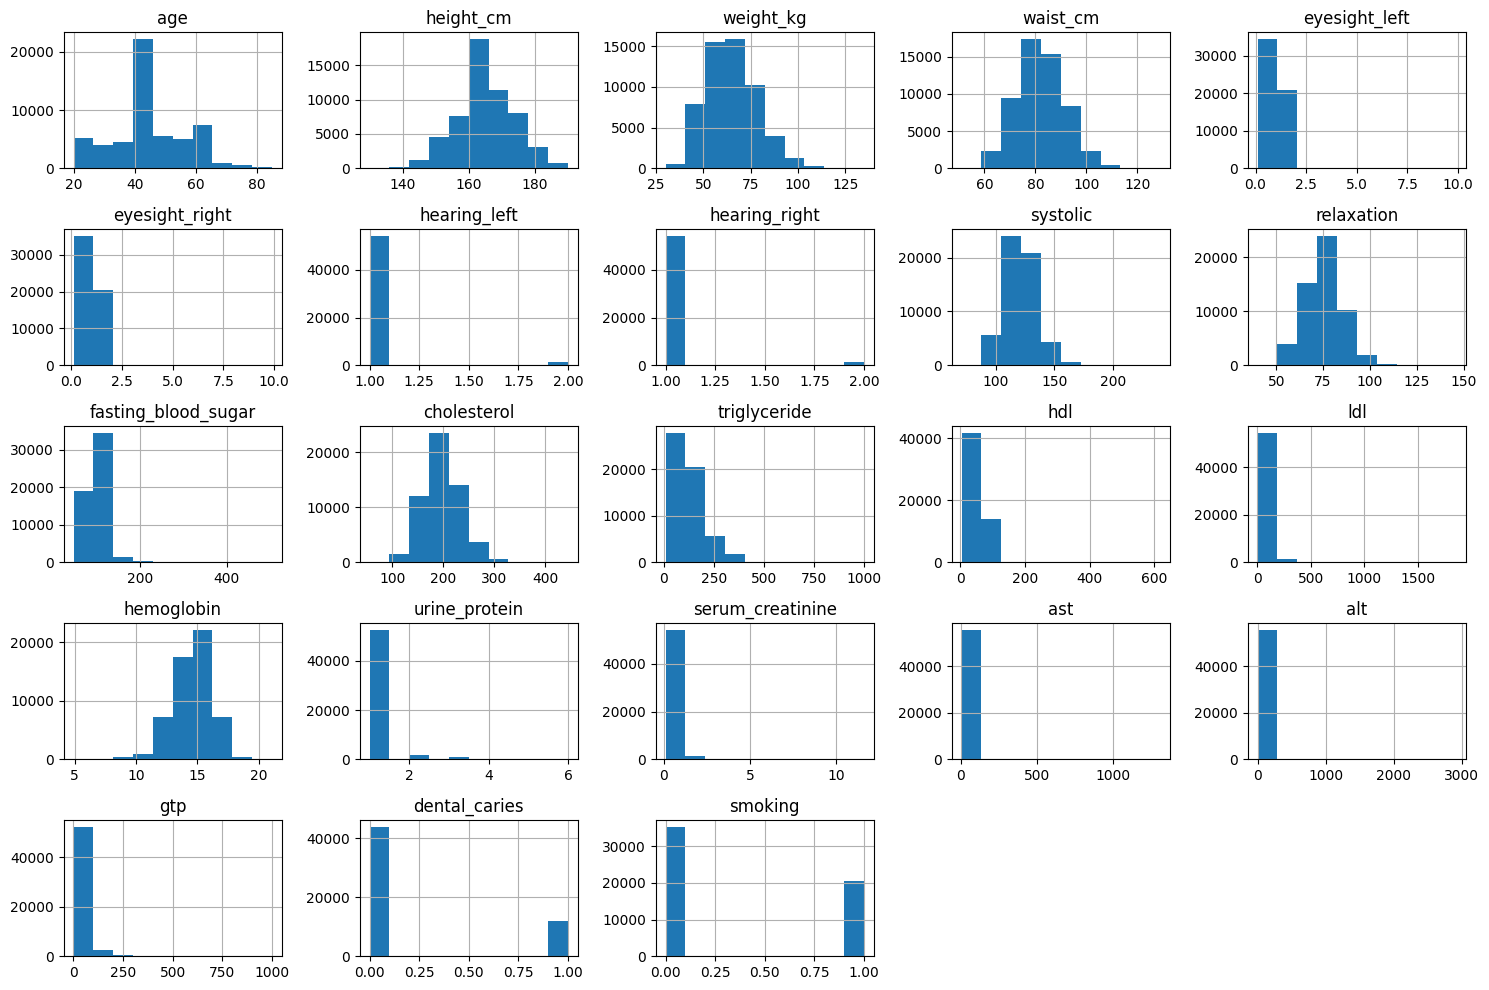

In [478]:
df.hist(figsize=(15, 10), bins=10)
plt.tight_layout()
plt.show()

In [479]:
print(f'Unikalne wartosci w kazdej kolumnie:\n')
df.nunique().sort_values()

Unikalne wartosci w kazdej kolumnie:



oral                     1
hearing_left             2
dental_caries            2
hearing_right            2
gender_M                 2
smoking                  2
tartar_Y                 2
urine_protein            6
height_cm               13
age                     14
eyesight_right          17
eyesight_left           19
weight_kg               22
serum_creatinine        38
relaxation              95
hdl                    126
systolic               130
hemoglobin             145
ast                    219
alt                    245
fasting_blood_sugar    276
cholesterol            286
ldl                    289
triglyceride           390
gtp                    488
waist_cm               566
dtype: int64

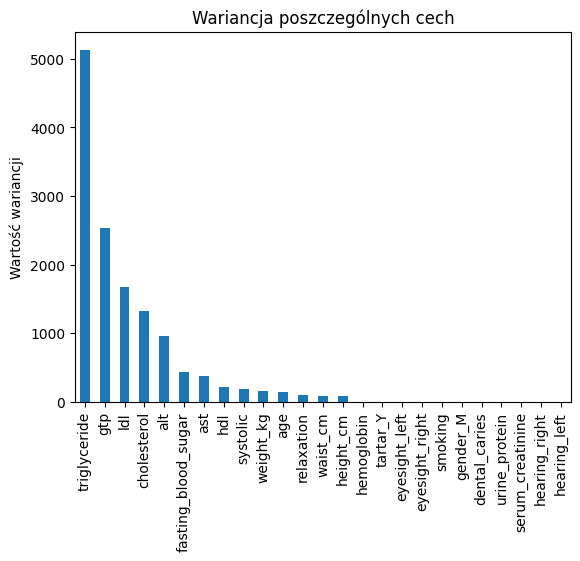

In [480]:
variances = df.var(numeric_only=True).sort_values(ascending=False)
variances.plot(kind='bar')
plt.title("Wariancja poszczególnych cech")
plt.ylabel("Wartość wariancji")
plt.show()

In [481]:
pearson_vars = ['age', 'height_cm', 'weight_kg', 'systolic', 'relaxation', 'hemoglobin']
spearman_vars = ['fasting_blood_sugar', 'triglyceride', 'hdl', 'ldl', 'ast', 'alt', 'gtp', 'serum_creatinine']
kendall_vars = ['hearing_left', 'hearing_right', 'urine_protein', 'dental_caries', 'tartar_Y', 'gender_M']

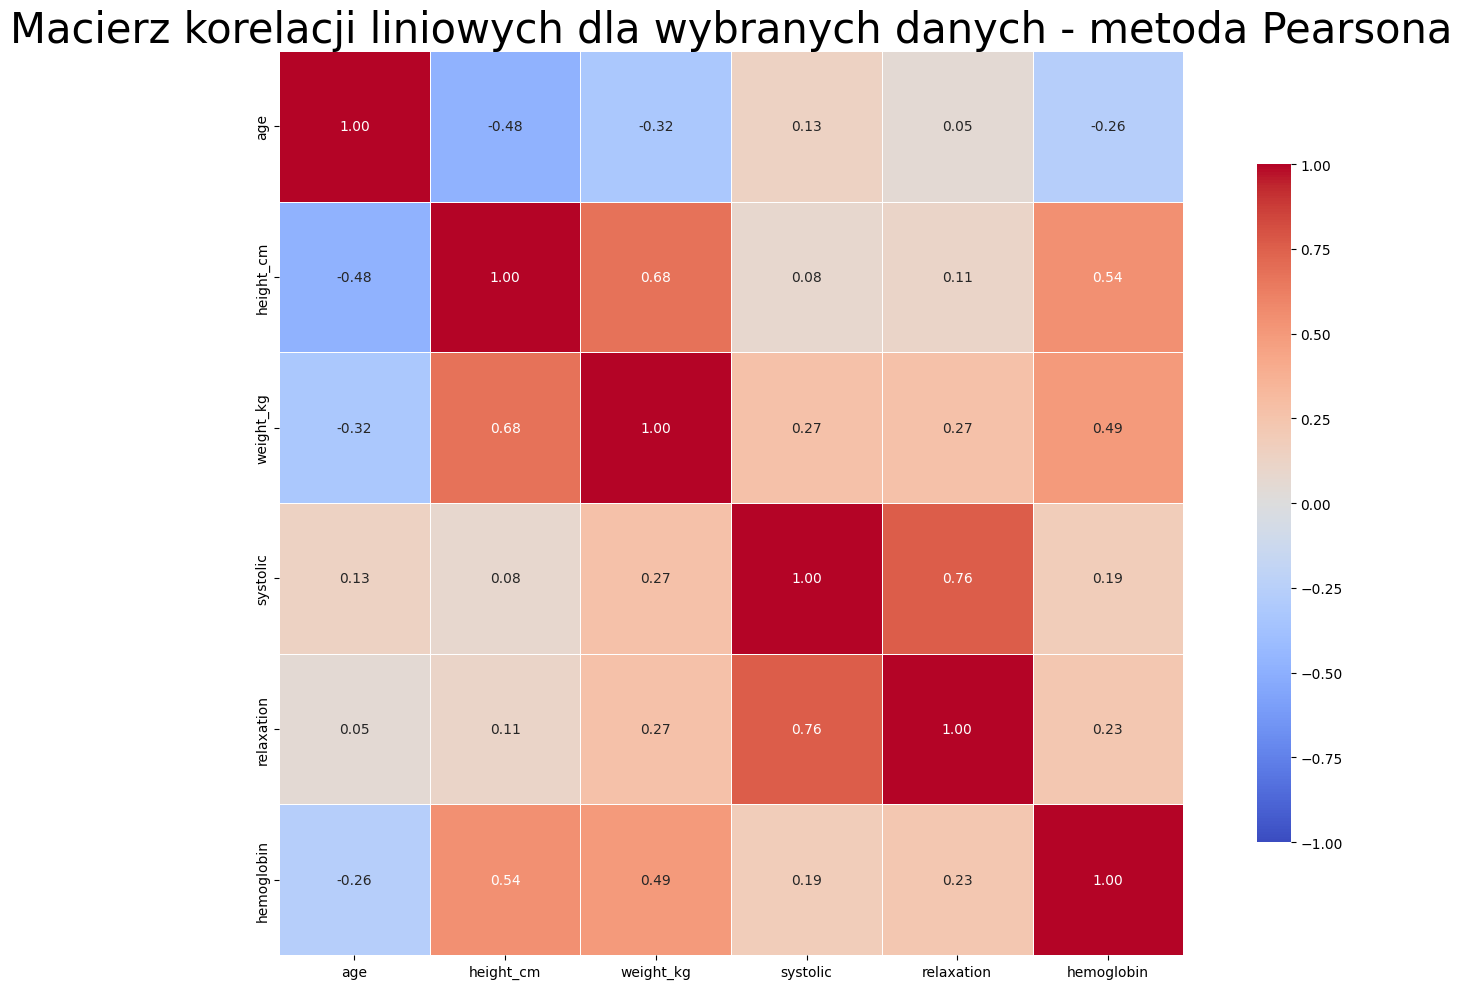

In [482]:
corr = df[pearson_vars].corr(numeric_only=True, method='pearson')
plt.figure(figsize=(15, 10))

sns.heatmap(corr, 
 annot=True, 
 fmt=".2f",
 cmap="coolwarm",
 vmin=-1, vmax=1,
 square=True,
 linewidths=0.5, 
 cbar_kws={"shrink": .75})  


plt.title("Macierz korelacji liniowych dla wybranych danych - metoda Pearsona", fontsize=30)
plt.tight_layout()
plt.show()

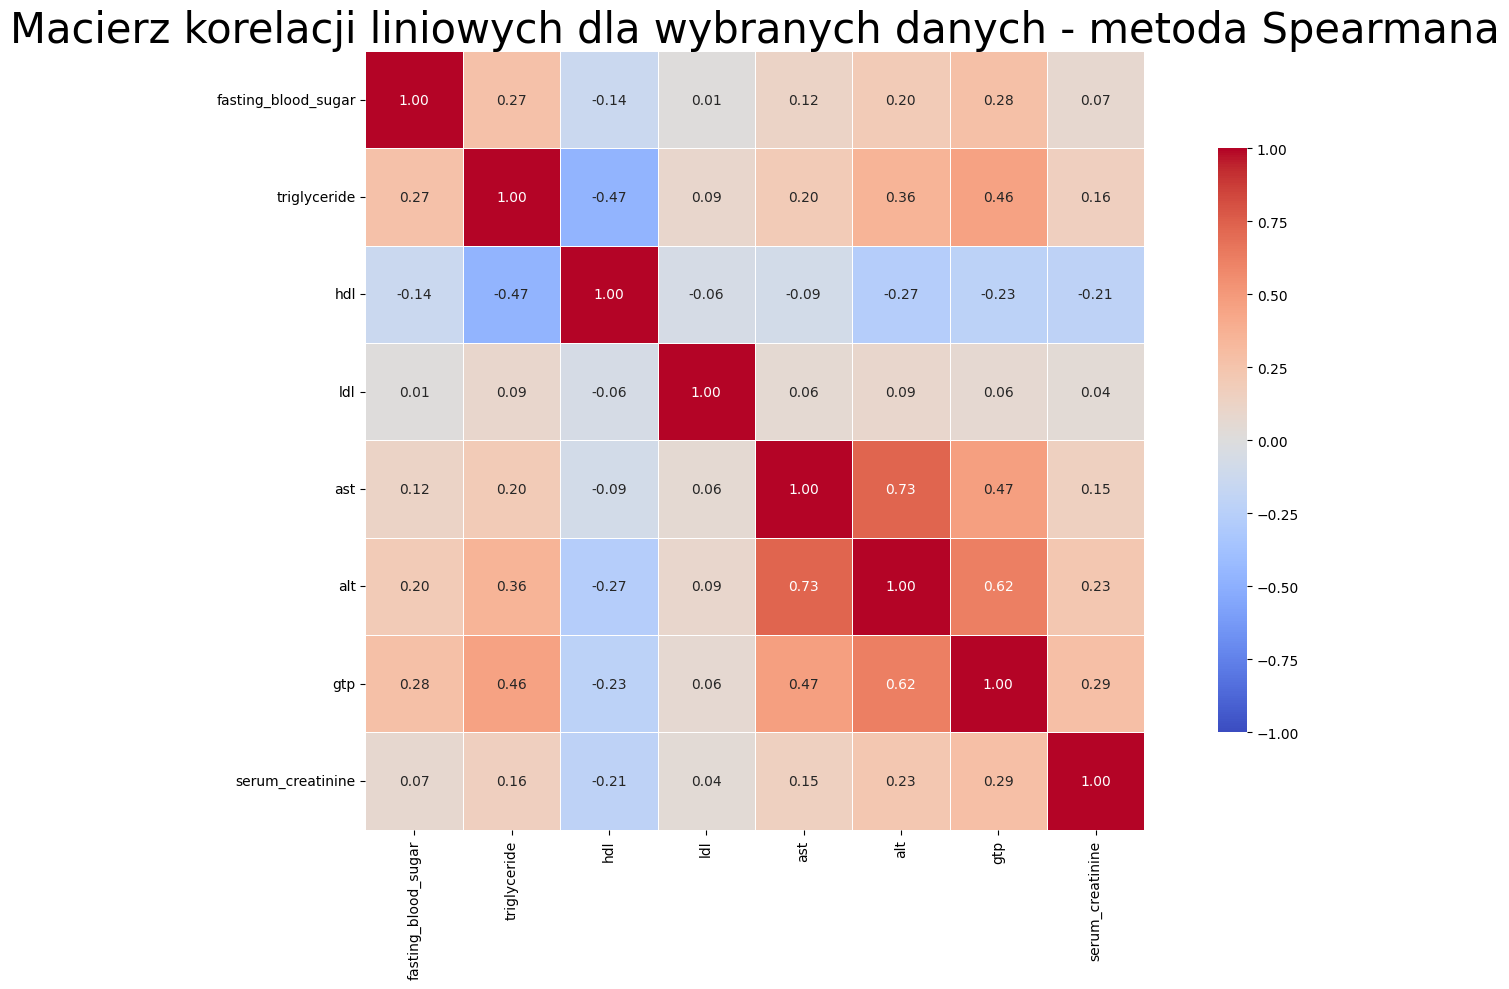

In [483]:
corr = df[spearman_vars].corr(numeric_only=True, method='spearman')
plt.figure(figsize=(15, 10))

sns.heatmap(corr, 
 annot=True, 
 fmt=".2f",
 cmap="coolwarm",
 vmin=-1, vmax=1,
 square=True,
 linewidths=0.5, 
 cbar_kws={"shrink": .75})  


plt.title("Macierz korelacji liniowych dla wybranych danych - metoda Spearmana", fontsize=30)
plt.tight_layout()
plt.show()

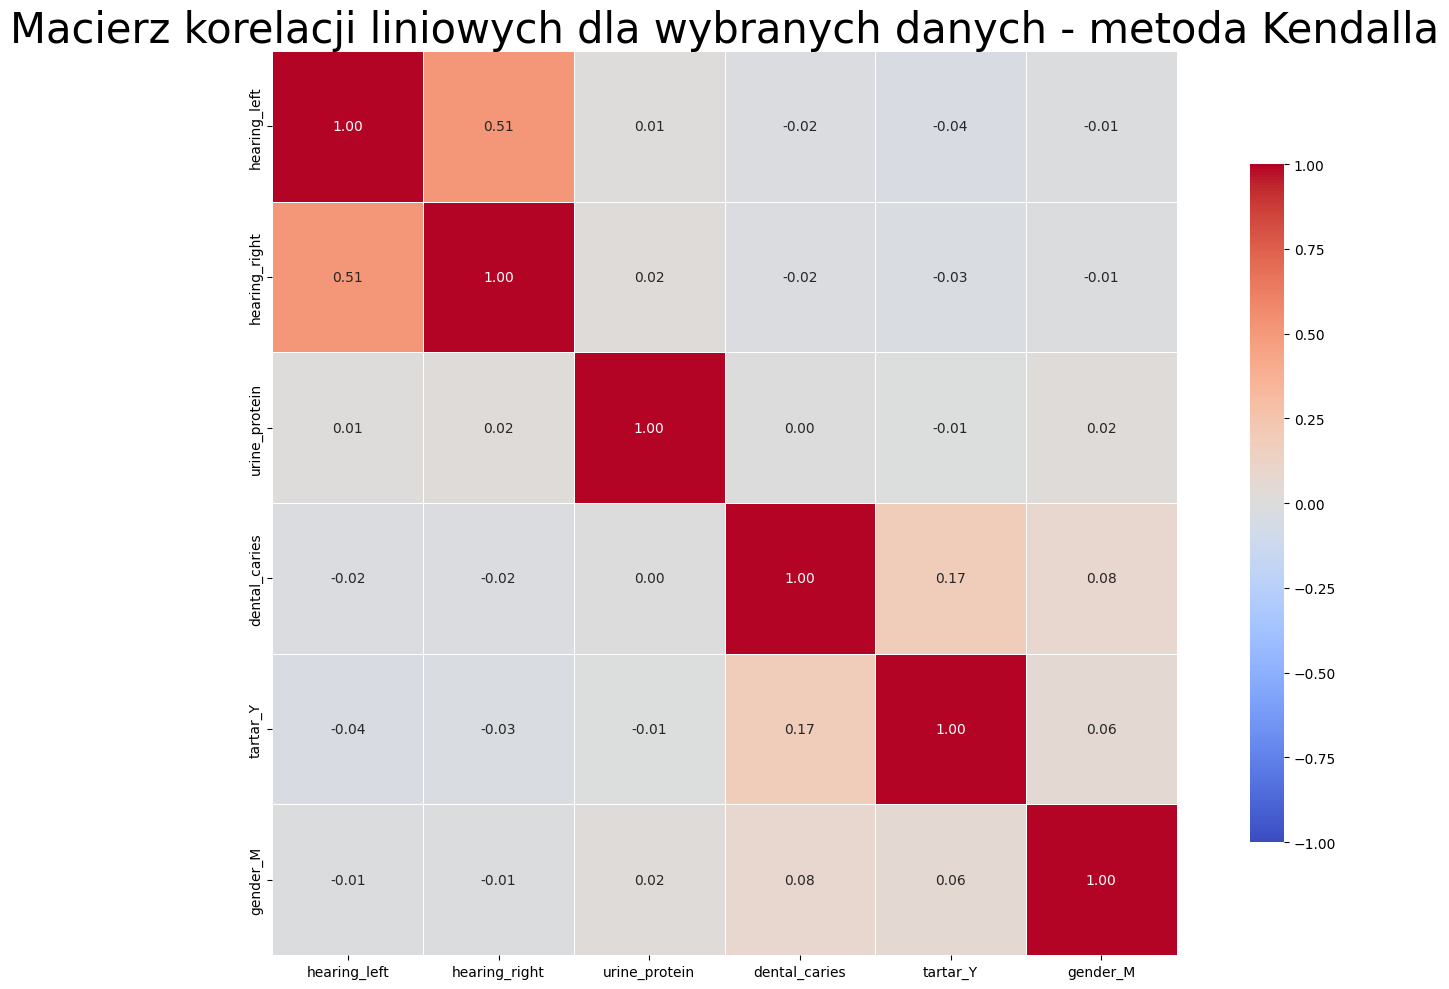

In [484]:
corr = df[kendall_vars].corr(numeric_only=True, method='kendall')
plt.figure(figsize=(15, 10))

sns.heatmap(corr, 
 annot=True, 
 fmt=".2f",
 cmap="coolwarm",
 vmin=-1, vmax=1,
 square=True,
 linewidths=0.5, 
 cbar_kws={"shrink": .75})  


plt.title("Macierz korelacji liniowych dla wybranych danych - metoda Kendalla", fontsize=30)
plt.tight_layout()
plt.show()

In [485]:
df["pulse_pressure"] = df["systolic"] - df["relaxation"]
df.head()

,age,height_cm,weight_kg,waist_cm,eyesight_left,eyesight_right,hearing_left,hearing_right,systolic,relaxation,...,serum_creatinine,ast,alt,gtp,oral,dental_caries,smoking,gender_M,tartar_Y,pulse_pressure
0,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,73.0,...,0.7,18.0,19.0,27.0,Y,0,0,False,True,41.0
1,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,70.0,...,0.6,22.0,19.0,18.0,Y,0,0,False,True,49.0
2,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,86.0,...,1.0,21.0,16.0,22.0,Y,0,1,True,False,52.0
3,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,60.0,...,1.0,19.0,26.0,18.0,Y,0,0,True,True,40.0
4,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,74.0,...,0.6,16.0,14.0,22.0,Y,0,0,False,False,46.0


In [486]:
df["BMI"] = (df["weight_kg"]/ (df['height_cm']/100) ** 2).round().astype(int)
df.head()

,age,height_cm,weight_kg,waist_cm,eyesight_left,eyesight_right,hearing_left,hearing_right,systolic,relaxation,...,ast,alt,gtp,oral,dental_caries,smoking,gender_M,tartar_Y,pulse_pressure,BMI
0,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,73.0,...,18.0,19.0,27.0,Y,0,0,False,True,41.0,25
1,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,70.0,...,22.0,19.0,18.0,Y,0,0,False,True,49.0,23
2,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,86.0,...,21.0,16.0,22.0,Y,0,1,True,False,52.0,21
3,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,60.0,...,19.0,26.0,18.0,Y,0,0,True,True,40.0,26
4,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,74.0,...,16.0,14.0,22.0,Y,0,0,False,False,46.0,25


In [487]:
df["liver_index_ast_alt_gtp_mean"] = df[["ast", "alt", "gtp"]].mean(axis=1).round().astype(int)

In [488]:
cols_to_drop = ['waist_cm','cholesterol', 'oral', 'relaxation', 'systolic', 'weight_kg', 'height_cm', 'ast', 'alt', 'gtp']
df = df.drop(cols_to_drop, axis=1)
df.head()

,age,eyesight_left,eyesight_right,hearing_left,hearing_right,fasting_blood_sugar,triglyceride,hdl,ldl,hemoglobin,urine_protein,serum_creatinine,dental_caries,smoking,gender_M,tartar_Y,pulse_pressure,BMI,liver_index_ast_alt_gtp_mean
0,40,1.2,1.0,1.0,1.0,94.0,82.0,73.0,126.0,12.9,1.0,0.7,0,0,False,True,41.0,25,21
1,40,0.8,0.6,1.0,1.0,130.0,115.0,42.0,127.0,12.7,1.0,0.6,0,0,False,True,49.0,23,20
2,55,0.8,0.8,1.0,1.0,89.0,182.0,55.0,151.0,15.8,1.0,1.0,0,1,True,False,52.0,21,20
3,40,1.5,1.5,1.0,1.0,96.0,254.0,45.0,226.0,14.7,1.0,1.0,0,0,True,True,40.0,26,21
4,40,1.0,1.0,1.0,1.0,80.0,74.0,62.0,107.0,12.5,1.0,0.6,0,0,False,False,46.0,25,17


In [489]:
df.columns

Index(['age', 'eyesight_left', 'eyesight_right', 'hearing_left',
       'hearing_right', 'fasting_blood_sugar', 'triglyceride', 'hdl', 'ldl',
       'hemoglobin', 'urine_protein', 'serum_creatinine', 'dental_caries',
       'smoking', 'gender_M', 'tartar_Y', 'pulse_pressure', 'BMI',
       'liver_index_ast_alt_gtp_mean'],
      dtype='object')

<span style="color: lightblue">

### 3. Modelling
<span>

In [490]:
X = df.drop('smoking', axis=1)
y = df['smoking']

In [491]:
feature_names = X.columns.tolist()
target_names = y.unique().tolist() 

print("Feature names:", feature_names)
print("Target names:", target_names)
print("Number of samples:", len(X))
print("Number of features:", X.shape[1])
print("\nDistribution of target variable:")
print(y.value_counts(normalize=True).round(2))

Feature names: ['age', 'eyesight_left', 'eyesight_right', 'hearing_left', 'hearing_right', 'fasting_blood_sugar', 'triglyceride', 'hdl', 'ldl', 'hemoglobin', 'urine_protein', 'serum_creatinine', 'dental_caries', 'gender_M', 'tartar_Y', 'pulse_pressure', 'BMI', 'liver_index_ast_alt_gtp_mean']
Target names: [0, 1]
Number of samples: 55692
Number of features: 18

Distribution of target variable:
smoking
0    0.63
1    0.37
Name: proportion, dtype: float64


In [493]:
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_tr_scaled = scaler.fit_transform(X_train)
X_ts_scaled = scaler.transform(X_test)


print("Number of training samples:", len(X_tr_scaled))
print("Number of test samples:", len(X_ts_scaled))


Number of training samples: 44553
Number of test samples: 11139


In [495]:
model = LogisticRegression(max_iter=1000)
model.fit(X_tr_scaled, y_train)

accuracy = model.score(X_ts_scaled, y_test)
print("Model accuracy:", accuracy)

Model accuracy: 0.7307657778974773


<span style="color: lightblue">

### 4. Optimalisation
<span>

<span style="color: lightblue">

### 5. Results interpretation
<span>